In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
import pandas as pd

PATH_PRICE   = '../datasets/raw_datasets/all_price_iduladha_2017_2026.csv'
PATH_WEATHER = '../datasets/raw_datasets/all_weather_nasa_2017_2026.csv'

df_price = pd.read_csv(PATH_PRICE)
df_weather = pd.read_csv(PATH_WEATHER)

print("Price shape:", df_price.shape)
print("Weather shape:", df_weather.shape)
print()
print(df_price.head(3))
print()
print(df_weather.head(3))

Price shape: (9455, 5)
Weather shape: (3434, 10)

  No                Komoditas Tanggal_Raw  Harga    Tahun_Sumber
0  I                    Beras  02/08/2017  10100  Idul Adha 2017
1  1   Beras Kualitas Bawah I  02/08/2017   9250  Idul Adha 2017
2  2  Beras Kualitas Bawah II  02/08/2017   8800  Idul Adha 2017

         Date  T2M_MIN  T2M_MAX    T2M   RH2M  PRECTOTCORR  ALLSKY_SFC_SW_DWN  \
0  2017-01-01    18.39    26.51  22.04  87.64         3.50              21.98   
1  2017-01-02    18.39    25.46  21.50  88.15         2.86              23.36   
2  2017-01-03    17.93    26.56  22.05  87.92         3.18              19.35   

   WS10M_MAX  WS10M  WD10M  
0       3.73   2.58  240.2  
1       5.31   3.40  232.6  
2       4.77   3.12  251.8  


##Eksplorasi Awal (Cek Kondisi Data)

In [35]:
print("=== PRICE ===")
print(df_price.dtypes)
print(df_price.isnull().sum())
print()
print("=== WEATHER ===")
print(df_weather.dtypes)
print(df_weather.isnull().sum())

=== PRICE ===
No              object
Komoditas       object
Tanggal_Raw     object
Harga            int64
Tahun_Sumber    object
dtype: object
No              0
Komoditas       0
Tanggal_Raw     0
Harga           0
Tahun_Sumber    0
dtype: int64

=== WEATHER ===
Date                  object
T2M_MIN              float64
T2M_MAX              float64
T2M                  float64
RH2M                 float64
PRECTOTCORR          float64
ALLSKY_SFC_SW_DWN    float64
WS10M_MAX            float64
WS10M                float64
WD10M                float64
dtype: object
Date                 0
T2M_MIN              0
T2M_MAX              0
T2M                  0
RH2M                 0
PRECTOTCORR          0
ALLSKY_SFC_SW_DWN    0
WS10M_MAX            0
WS10M                0
WD10M                0
dtype: int64


##Cleaning Data PIHPS (Harga)

In [36]:
# 1. Hapus baris header kategori (No = I, II, III, dst.)
df_price = df_price[~df_price['No'].astype(str).str.match(r'^[IVX]+$')]
df_price = df_price.reset_index(drop=True)

# 2. Konversi tanggal ke format datetime
df_price['Tanggal'] = pd.to_datetime(df_price['Tanggal_Raw'], dayfirst=True)

# 3. Hapus kolom Tanggal_Raw karena sudah diganti
df_price = df_price.drop(columns=['Tanggal_Raw'])

# 4. Pastikan Harga numerik
df_price['Harga'] = pd.to_numeric(df_price['Harga'], errors='coerce')

# 5. Cek hasilnya
print(df_price.shape)
print(df_price.head())
print(df_price.dtypes)

(6405, 5)
  No                 Komoditas  Harga    Tahun_Sumber    Tanggal
0  1    Beras Kualitas Bawah I   9250  Idul Adha 2017 2017-08-02
1  2   Beras Kualitas Bawah II   8800  Idul Adha 2017 2017-08-02
2  3   Beras Kualitas Medium I  10250  Idul Adha 2017 2017-08-02
3  4  Beras Kualitas Medium II   9900  Idul Adha 2017 2017-08-02
4  5    Beras Kualitas Super I  11800  Idul Adha 2017 2017-08-02
No                      object
Komoditas               object
Harga                    int64
Tahun_Sumber            object
Tanggal         datetime64[ns]
dtype: object


##Filter Hanya Komoditas Sub-kategori (bukan agregat)

In [37]:
# Komoditas agregat (level atas) - ini yang dihapus
kategori_agregat = [
    'Beras', 'Daging Ayam', 'Daging Sapi', 'Telur Ayam',
    'Bawang Merah', 'Bawang Putih', 'Cabai Merah',
    'Cabai Rawit', 'Minyak Goreng', 'Gula Pasir'
]

df_price = df_price[~df_price['Komoditas'].isin(kategori_agregat)]
df_price = df_price.reset_index(drop=True)

print("Komoditas yang tersisa:", df_price['Komoditas'].unique().tolist())
print("Shape:", df_price.shape)

Komoditas yang tersisa: ['Beras Kualitas Bawah I', 'Beras Kualitas Bawah II', 'Beras Kualitas Medium I', 'Beras Kualitas Medium II', 'Beras Kualitas Super I', 'Beras Kualitas Super II', 'Daging Ayam Ras Segar', 'Daging Sapi Kualitas 1', 'Daging Sapi Kualitas 2', 'Telur Ayam Ras Segar', 'Bawang Merah Ukuran Sedang', 'Bawang Putih Ukuran Sedang', 'Cabai Merah Besar', 'Cabai Merah Keriting ', 'Cabai Rawit Hijau', 'Cabai Rawit Merah', 'Minyak Goreng Curah', 'Minyak Goreng Kemasan Bermerk 1', 'Minyak Goreng Kemasan Bermerk 2', 'Gula Pasir Kualitas Premium', 'Gula Pasir Lokal']
Shape: (6405, 5)


##Cleaning Data NASA (Cuaca)

In [38]:
# 1. Konversi tanggal
df_weather['Date'] = pd.to_datetime(df_weather['Date'])

# 2. Cek missing value (NASA pakai -999 sebagai penanda data kosong)
print("Nilai -999 per kolom:")
print((df_weather == -999).sum())

# 3. Ganti -999 dengan NaN
df_weather = df_weather.replace(-999, np.nan)

# 4. Cek ulang
print("\nMissing setelah replace:")
print(df_weather.isnull().sum())

Nilai -999 per kolom:
Date                 0
T2M_MIN              5
T2M_MAX              5
T2M                  5
RH2M                 5
PRECTOTCORR          5
ALLSKY_SFC_SW_DWN    6
WS10M_MAX            5
WS10M                5
WD10M                5
dtype: int64

Missing setelah replace:
Date                 0
T2M_MIN              5
T2M_MAX              5
T2M                  5
RH2M                 5
PRECTOTCORR          5
ALLSKY_SFC_SW_DWN    6
WS10M_MAX            5
WS10M                5
WD10M                5
dtype: int64


## Filter Data Cuaca Sesuai Periode Idul Adha

In [39]:
# Tanggal Idul Adha per tahun (1 Dzulhijjah = hari H)
idul_adha_dates = {
    2017: '2017-09-01',
    2018: '2018-08-22',
    2019: '2019-08-11',
    2020: '2020-07-31',
    2021: '2021-07-20',
    2022: '2022-07-10',
    2023: '2023-06-29',
    2024: '2024-06-17',
    2025: '2025-06-07',
    2026: '2026-05-27',
}

# Buat mask filter: ambil H-30 sampai H+15 tiap tahun
masks = []
for year, date_str in idul_adha_dates.items():
    hari_h = pd.to_datetime(date_str)
    start  = hari_h - pd.Timedelta(days=30)
    end    = hari_h + pd.Timedelta(days=15)
    mask   = (df_weather['Date'] >= start) & (df_weather['Date'] <= end)
    masks.append(mask)

# Gabungkan semua mask dengan OR
combined_mask = masks[0]
for m in masks[1:]:
    combined_mask = combined_mask | m

df_weather_filtered = df_weather[combined_mask].reset_index(drop=True)

print("Weather setelah filter:", df_weather_filtered.shape)
print("Rentang tanggal:", df_weather_filtered['Date'].min(), "s/d", df_weather_filtered['Date'].max())

Weather setelah filter: (445, 10)
Rentang tanggal: 2017-08-02 00:00:00 s/d 2026-05-27 00:00:00


##Handle Weekend di Data PIHPS

In [40]:
# Buat dataframe lengkap (semua hari kalender) per komoditas per tahun
komoditas_list = df_price['Komoditas'].unique()

expanded_list = []
for tahun_src in df_price['Tahun_Sumber'].unique():
    df_tahun = df_price[df_price['Tahun_Sumber'] == tahun_src]
    tgl_min  = df_tahun['Tanggal'].min()
    tgl_max  = df_tahun['Tanggal'].max()
    full_range = pd.date_range(start=tgl_min, end=tgl_max, freq='D')

    for komoditas in komoditas_list:
        df_kom = df_tahun[df_tahun['Komoditas'] == komoditas][['Tanggal', 'Harga']].copy()
        df_kom = df_kom.set_index('Tanggal').reindex(full_range)
        df_kom.index.name = 'Tanggal'
        df_kom['Harga'] = df_kom['Harga'].ffill()  # forward fill weekend
        df_kom['Komoditas'] = komoditas
        df_kom['Tahun_Sumber'] = tahun_src
        df_kom = df_kom.reset_index()
        expanded_list.append(df_kom)

df_price_daily = pd.concat(expanded_list, ignore_index=True)
print("Shape setelah expand weekend:", df_price_daily.shape)
print(df_price_daily.head())

Shape setelah expand weekend: (8967, 4)
     Tanggal   Harga               Komoditas    Tahun_Sumber
0 2017-08-02  9250.0  Beras Kualitas Bawah I  Idul Adha 2017
1 2017-08-03  9400.0  Beras Kualitas Bawah I  Idul Adha 2017
2 2017-08-04  9400.0  Beras Kualitas Bawah I  Idul Adha 2017
3 2017-08-05  9400.0  Beras Kualitas Bawah I  Idul Adha 2017
4 2017-08-06  9400.0  Beras Kualitas Bawah I  Idul Adha 2017


##Feature Engineering (Fitur Baru)

In [41]:
# Tambahkan tanggal Idul Adha ke df_price_daily untuk kalkulasi fitur
idul_adha_map = {v: pd.to_datetime(v) for v in idul_adha_dates.values()}
tahun_to_idul = {str(k): pd.to_datetime(v) for k, v in idul_adha_dates.items()}

def get_idul_adha(tahun_sumber_str):
    tahun = tahun_sumber_str.split()[-1]
    return tahun_to_idul.get(tahun, pd.NaT)

df_price_daily['Idul_Adha_Date'] = df_price_daily['Tahun_Sumber'].apply(get_idul_adha)

# Fitur 1: Days_to_Idul_Adha
df_price_daily['Days_to_Idul_Adha'] = (
    df_price_daily['Tanggal'] - df_price_daily['Idul_Adha_Date']
).dt.days

# Fitur 2: Is_Pre_Idul_Adha (H-30 s/d H-1)
df_price_daily['Is_Pre_Idul_Adha'] = (
    (df_price_daily['Days_to_Idul_Adha'] >= -30) &
    (df_price_daily['Days_to_Idul_Adha'] < 0)
).astype(int)

# Fitur 3: Is_Idul_Adha_Week (H-3 s/d H+3)
df_price_daily['Is_Idul_Adha_Week'] = (
    df_price_daily['Days_to_Idul_Adha'].between(-3, 3)
).astype(int)

# Fitur 4: Day_of_Week
df_price_daily['Day_of_Week'] = df_price_daily['Tanggal'].dt.dayofweek

# Fitur 5: Is_Weekend
df_price_daily['Is_Weekend'] = (df_price_daily['Day_of_Week'] >= 5).astype(int)

print(df_price_daily[['Tanggal', 'Komoditas', 'Harga', 'Days_to_Idul_Adha',
                        'Is_Pre_Idul_Adha', 'Is_Idul_Adha_Week']].head(10))

     Tanggal               Komoditas   Harga  Days_to_Idul_Adha  \
0 2017-08-02  Beras Kualitas Bawah I  9250.0                -30   
1 2017-08-03  Beras Kualitas Bawah I  9400.0                -29   
2 2017-08-04  Beras Kualitas Bawah I  9400.0                -28   
3 2017-08-05  Beras Kualitas Bawah I  9400.0                -27   
4 2017-08-06  Beras Kualitas Bawah I  9400.0                -26   
5 2017-08-07  Beras Kualitas Bawah I  9400.0                -25   
6 2017-08-08  Beras Kualitas Bawah I  9400.0                -24   
7 2017-08-09  Beras Kualitas Bawah I  9400.0                -23   
8 2017-08-10  Beras Kualitas Bawah I  9400.0                -22   
9 2017-08-11  Beras Kualitas Bawah I  9400.0                -21   

   Is_Pre_Idul_Adha  Is_Idul_Adha_Week  
0                 1                  0  
1                 1                  0  
2                 1                  0  
3                 1                  0  
4                 1                  0  
5               

##Merge Dataset Harga + Cuaca

In [42]:
# Rename kolom tanggal supaya sama
df_weather_filtered = df_weather_filtered.rename(columns={'Date': 'Tanggal'})

# Merge berdasarkan tanggal
df_merged = pd.merge(
    df_price_daily,
    df_weather_filtered,
    on='Tanggal',
    how='left'  # pertahankan semua baris harga, isi cuaca jika ada
)

print("Shape merged:", df_merged.shape)
print("Missing values setelah merge:")
print(df_merged.isnull().sum())

kolom_cuaca = ['T2M_MIN','T2M_MAX','T2M','RH2M','PRECTOTCORR',
               'ALLSKY_SFC_SW_DWN','WS10M_MAX','WS10M','WD10M']

# Sort dulu supaya interpolasi linear masuk akal
df_merged = df_merged.sort_values(['Komoditas','Tanggal']).reset_index(drop=True)

for col in kolom_cuaca:
    df_merged[col] = df_merged[col].interpolate(method='linear', limit_direction='both')

print("Missing setelah fix:")
print(df_merged[kolom_cuaca].isnull().sum())

Shape merged: (8967, 19)
Missing values setelah merge:
Tanggal               0
Harga                 0
Komoditas             0
Tahun_Sumber          0
Idul_Adha_Date        0
Days_to_Idul_Adha     0
Is_Pre_Idul_Adha      0
Is_Idul_Adha_Week     0
Day_of_Week           0
Is_Weekend            0
T2M_MIN              84
T2M_MAX              84
T2M                  84
RH2M                 84
PRECTOTCORR          84
ALLSKY_SFC_SW_DWN    84
WS10M_MAX            84
WS10M                84
WD10M                84
dtype: int64
Missing setelah fix:
T2M_MIN              0
T2M_MAX              0
T2M                  0
RH2M                 0
PRECTOTCORR          0
ALLSKY_SFC_SW_DWN    0
WS10M_MAX            0
WS10M                0
WD10M                0
dtype: int64


##Handle Missing Value Cuaca setelah Merge

In [43]:
# Kolom cuaca yang mungkin NaN setelah merge (isi dengan interpolasi)
kolom_cuaca = ['T2M_MIN', 'T2M_MAX', 'T2M', 'RH2M', 'PRECTOTCORR',
               'ALLSKY_SFC_SW_DWN', 'WS10M_MAX', 'WS10M', 'WD10M']

for col in kolom_cuaca:
    df_merged[col] = df_merged[col].interpolate(method='linear', limit_direction='both')

print("Missing setelah interpolasi:")
print(df_merged[kolom_cuaca].isnull().sum())

Missing setelah interpolasi:
T2M_MIN              0
T2M_MAX              0
T2M                  0
RH2M                 0
PRECTOTCORR          0
ALLSKY_SFC_SW_DWN    0
WS10M_MAX            0
WS10M                0
WD10M                0
dtype: int64


##Validasi & Fix Tipe Data

In [44]:
# Fix tipe data datetime
df_merged['Tanggal']        = pd.to_datetime(df_merged['Tanggal'])
df_merged['Idul_Adha_Date'] = pd.to_datetime(df_merged['Idul_Adha_Date'])

# Konfirmasi
print(df_merged[['Tanggal','Idul_Adha_Date','Harga']].dtypes)

Tanggal           datetime64[ns]
Idul_Adha_Date    datetime64[ns]
Harga                    float64
dtype: object


##Cek & Dokumentasi Outlier Harga


In [45]:
# Outlier pakai IQR — jangan dihapus, tapi dokumentasikan
outlier_summary = []

for kom in df_merged['Komoditas'].unique():
    subset = df_merged[df_merged['Komoditas'] == kom]['Harga']
    Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
    IQR    = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_outlier = ((subset < lower) | (subset > upper)).sum()
    outlier_summary.append({'Komoditas': kom, 'Lower': lower, 'Upper': upper, 'N_Outlier': n_outlier})

df_outlier = pd.DataFrame(outlier_summary)
print(df_outlier[df_outlier['N_Outlier'] > 0])
# Catatan: outlier pada cabai & bawang adalah wajar secara kontekstual
# (fluktuasi musiman antar tahun 2017-2026), BUKAN error data

                     Komoditas    Lower     Upper  N_Outlier
0   Bawang Merah Ukuran Sedang   3187.5   67687.5         10
8            Cabai Merah Besar -14250.0  106150.0          7
9        Cabai Merah Keriting  -14212.5   94087.5         12
10           Cabai Rawit Hijau  -7825.0   93575.0          2
11           Cabai Rawit Merah  -2350.0  110850.0          2
12       Daging Ayam Ras Segar  27625.0   43025.0          5


##Encoding Musiman dan feature engineering setelah di merge

In [46]:
# Encoding musiman
df_merged['Bulan']             = df_merged['Tanggal'].dt.month
df_merged['Minggu_ke']         = df_merged['Tanggal'].dt.isocalendar().week.astype(int)
df_merged['Hari_dalam_minggu'] = df_merged['Tanggal'].dt.dayofweek

# Cyclic encoding
df_merged['Bulan_sin'] = np.sin(2 * np.pi * df_merged['Bulan'] / 12)
df_merged['Bulan_cos'] = np.cos(2 * np.pi * df_merged['Bulan'] / 12)

# Sort dulu sebelum lag & MA — WAJIB
df_merged = df_merged.sort_values(['Komoditas', 'Tanggal']).reset_index(drop=True)

# Lag features
for lag in [1, 3, 7]:
    df_merged[f'Harga_lag_{lag}'] = df_merged.groupby('Komoditas')['Harga'].shift(lag)

# Moving average
for window in [3, 7]:
    df_merged[f'MA_{window}'] = (
        df_merged.groupby('Komoditas')['Harga']
        .transform(lambda x: x.rolling(window, min_periods=1).mean())
    )

# Verifikasi
print(df_merged[['Tanggal','Komoditas','Harga','Harga_lag_1','Harga_lag_7','MA_3','MA_7']].head(10))
print()
print("Kolom lag & MA:", [c for c in df_merged.columns if 'lag' in c or 'MA_' in c])
print("Missing di lag (wajar untuk baris awal tiap komoditas):")
print(df_merged[['Harga_lag_1','Harga_lag_3','Harga_lag_7']].isnull().sum())

     Tanggal                   Komoditas    Harga  Harga_lag_1  Harga_lag_7  \
0 2017-08-02  Bawang Merah Ukuran Sedang  25400.0          NaN          NaN   
1 2017-08-03  Bawang Merah Ukuran Sedang  25400.0      25400.0          NaN   
2 2017-08-04  Bawang Merah Ukuran Sedang  24100.0      25400.0          NaN   
3 2017-08-05  Bawang Merah Ukuran Sedang  24100.0      24100.0          NaN   
4 2017-08-06  Bawang Merah Ukuran Sedang  24100.0      24100.0          NaN   
5 2017-08-07  Bawang Merah Ukuran Sedang  24750.0      24100.0          NaN   
6 2017-08-08  Bawang Merah Ukuran Sedang  24000.0      24750.0          NaN   
7 2017-08-09  Bawang Merah Ukuran Sedang  23650.0      24000.0      25400.0   
8 2017-08-10  Bawang Merah Ukuran Sedang  23650.0      23650.0      25400.0   
9 2017-08-11  Bawang Merah Ukuran Sedang  23250.0      23650.0      24100.0   

           MA_3          MA_7  
0  25400.000000  25400.000000  
1  25400.000000  25400.000000  
2  24966.666667  24966.666667  
3 

## Cek Korelasi Cuaca vs Harga

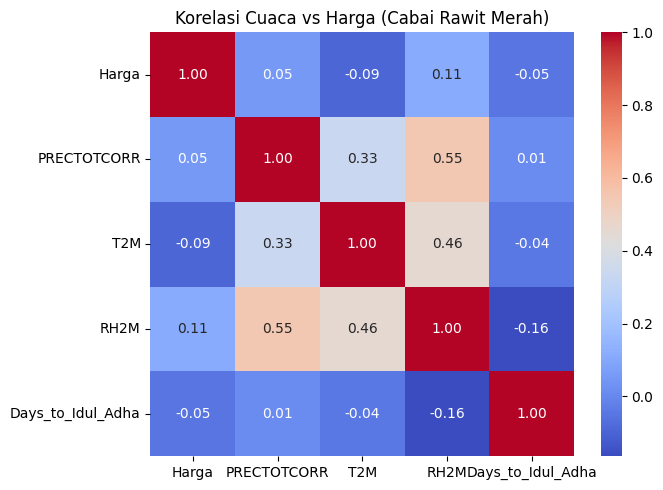

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil sampel: cabai rawit merah saja dulu (paling volatile)
df_cabai = df_merged[df_merged['Komoditas'] == 'Cabai Rawit Merah']

kolom_analisis = ['Harga','PRECTOTCORR','T2M','RH2M','Days_to_Idul_Adha']
corr_matrix    = df_cabai[kolom_analisis].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Korelasi Cuaca vs Harga (Cabai Rawit Merah)')
plt.tight_layout()
plt.show()

##Simpan Data Set Bersih

In [48]:
OUTPUT_PATH = '../datasets/clean_merged_dataset.csv'

df_merged.to_csv(OUTPUT_PATH, index=False)

print(f"Dataset bersih disimpan: {OUTPUT_PATH}")
print(f"Shape final: {df_merged.shape}")
print(df_merged.head())

Dataset bersih disimpan: clean_merged_dataset.csv
Shape final: (8967, 29)
     Tanggal    Harga                   Komoditas    Tahun_Sumber  \
0 2017-08-02  25400.0  Bawang Merah Ukuran Sedang  Idul Adha 2017   
1 2017-08-03  25400.0  Bawang Merah Ukuran Sedang  Idul Adha 2017   
2 2017-08-04  24100.0  Bawang Merah Ukuran Sedang  Idul Adha 2017   
3 2017-08-05  24100.0  Bawang Merah Ukuran Sedang  Idul Adha 2017   
4 2017-08-06  24100.0  Bawang Merah Ukuran Sedang  Idul Adha 2017   

  Idul_Adha_Date  Days_to_Idul_Adha  Is_Pre_Idul_Adha  Is_Idul_Adha_Week  \
0     2017-09-01                -30                 1                  0   
1     2017-09-01                -29                 1                  0   
2     2017-09-01                -28                 1                  0   
3     2017-09-01                -27                 1                  0   
4     2017-09-01                -26                 1                  0   

   Day_of_Week  Is_Weekend  ...  Bulan  Minggu_ke  Har